=== Vista general ===
   Cliente_ID  Edad        Ciudad  Ingresos  Gasto_Mensual  Frecuencia_Compra
0           1    21        Bogotá   1711957        3328769                  6
1           2    65          Cali   3110433        2080220                 20
2           3    20      Medellín   4612718        3601184                 17
3           4    41  Barranquilla   5211645        2550166                  2
4           5    19          Cali   4899812        2971479                 13

=== Tipos y nulos ===
<class 'pandas.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Cliente_ID         120 non-null    int64
 1   Edad               120 non-null    int64
 2   Ciudad             120 non-null    str  
 3   Ingresos           120 non-null    int64
 4   Gasto_Mensual      120 non-null    int64
 5   Frecuencia_Compra  120 non-null    int64
dtypes: int64(5), str(1)
m

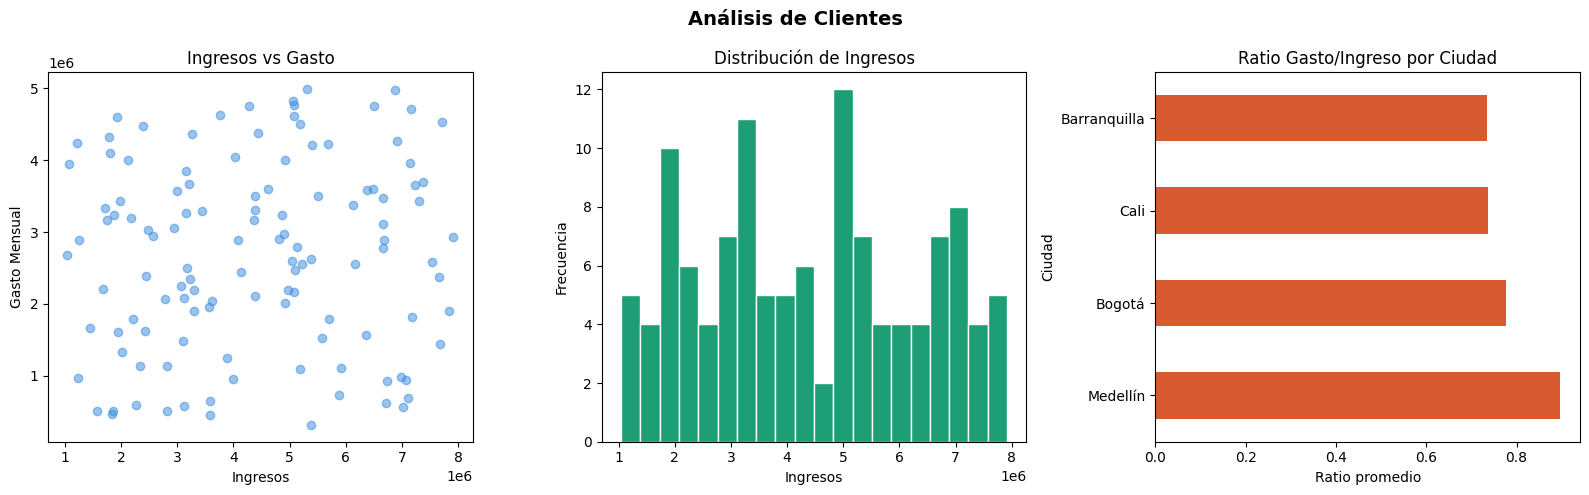


Análisis completado. Gráfico guardado como analisis_clientes.png


In [13]:
import pandas as pd
import matplotlib.pyplot as plt

# ─── 1. CARGA DE DATOS ───────────────────────────────────────────
df = pd.read_csv("dataset_clientes.csv")

# ─── 2. EXPLORACIÓN ──────────────────────────────────────────────
print("=== Vista general ===")
print(df.head())
print("\n=== Tipos y nulos ===")
print(df.info())
print("\n=== Estadísticas descriptivas ===")
print(df.describe())

# ─── 3. LIMPIEZA ─────────────────────────────────────────────────
print("\n=== Valores nulos por columna ===")
print(df.isnull().sum())

# Eliminar filas con nulos en columnas clave
df = df.dropna(subset=["Ingresos", "Gasto_Mensual", "Ciudad"])

# Eliminar duplicados
df = df.drop_duplicates()

print(f"\nRegistros después de limpieza: {len(df)}")

# ─── 4. ANÁLISIS ─────────────────────────────────────────────────
print("\n=== Ingreso promedio por ciudad ===")
ingreso_ciudad = df.groupby("Ciudad")["Ingresos"].mean().sort_values(ascending=False)
print(ingreso_ciudad)

# Métrica: ratio de gasto sobre ingresos
df["Ratio_Gasto"] = df["Gasto_Mensual"] / df["Ingresos"]

print("\n=== Ratio de gasto promedio por ciudad ===")
ratio_ciudad = df.groupby("Ciudad")["Ratio_Gasto"].mean().sort_values(ascending=False)
print(ratio_ciudad)

# ─── 5. VISUALIZACIONES ──────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Análisis de Clientes", fontsize=14, fontweight="bold")

# Gráfico 1: Scatter ingresos vs gasto
axes[0].scatter(df["Ingresos"], df["Gasto_Mensual"], alpha=0.5, color="#378ADD")
axes[0].set_xlabel("Ingresos")
axes[0].set_ylabel("Gasto Mensual")
axes[0].set_title("Ingresos vs Gasto")

# Gráfico 2: Histograma de ingresos
axes[1].hist(df["Ingresos"], bins=20, color="#1D9E75", edgecolor="white")
axes[1].set_xlabel("Ingresos")
axes[1].set_ylabel("Frecuencia")
axes[1].set_title("Distribución de Ingresos")

# Gráfico 3: Ratio de gasto por ciudad
ratio_ciudad.plot(kind="barh", ax=axes[2], color="#D85A30")
axes[2].set_xlabel("Ratio promedio")
axes[2].set_title("Ratio Gasto/Ingreso por Ciudad")

plt.tight_layout()
plt.savefig("analisis_clientes.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nAnálisis completado. Gráfico guardado como analisis_clientes.png")

- Se observa una relación positiva entre ingresos y gasto mensual, lo que indica que clientes con mayores ingresos tienden a gastar más.

- Existen diferencias en los ingresos promedio por ciudad, lo que sugiere variaciones en el poder adquisitivo.

- La distribución de ingresos muestra variabilidad entre clientes, lo que permite identificar distintos segmentos.

- El ratio de gasto permite identificar clientes que gastan una proporción alta de sus ingresos, lo que puede ser relevante para segmentación o análisis de riesgo.